<a href="https://colab.research.google.com/github/hanna04107-wq/CPI-PREDICTION-USING-MACROECONOMIC-INDICATORS-AND-MACHINE-LEARNING-MODEL/blob/main/FYP_CODING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **ANALISIS DESKRIPTIF**

In [3]:
import matplotlib.pyplot as plt
import numpy as mp
import pandas as pd

In [4]:
df_data   = pd.read_csv("/content/Final_Macroeconomic_Dataset_2013_2026_Jan.csv")

In [5]:
df_data.head()

,Date,Year,Month,CPI_Index,USD_Avg,M3_Total,OPR_Rate,PPI_Index,Unemployment_Rate
0,2013-01-01,2013,1,105.9,3.0390,1375858.0,3.0,107.9,3.4
1,2013-02-01,2013,2,106.1,3.0978,1379389.6,3.0,109.6,3.0
2,2013-03-01,2013,3,106.2,3.1076,1392122.9,3.0,108.2,3.2
3,2013-04-01,2013,4,106.3,3.0498,1399798.9,3.0,107.3,3.0
4,2013-05-01,2013,5,106.6,3.0168,1414632.1,3.0,106.6,3.2


In [6]:
df_data.describe()

,Year,Month,CPI_Index,USD_Avg,M3_Total,OPR_Rate,PPI_Index,Unemployment_Rate
count,157.000000,157.000000,157.000000,157.000000,1.570000e+02,157.000000,157.000000,157.000000
mean,2019.044586,6.464968,121.282803,4.086168,1.939963e+06,2.816879,110.154777,3.476433
std,3.783134,3.479848,8.287225,0.438620,3.558274e+05,0.497898,6.764997,0.548908
min,2013.000000,1.000000,105.900000,3.016800,1.375858e+06,1.750000,99.000000,2.600000
25%,2016.000000,3.000000,114.800000,4.026900,1.611143e+06,2.750000,105.000000,3.200000
50%,2019.000000,6.000000,120.900000,4.177600,1.913308e+06,3.000000,108.300000,3.300000
75%,2022.000000,9.000000,128.600000,4.348100,2.257146e+06,3.250000,116.300000,3.500000
max,2026.000000,12.000000,135.700000,4.772300,2.591322e+06,3.250000,124.100000,5.300000


In [7]:
df_data.dtypes

,0
Date,object
Year,int64
Month,int64
CPI_Index,float64
USD_Avg,float64
M3_Total,float64
OPR_Rate,float64
PPI_Index,float64
Unemployment_Rate,float64


In [8]:
# 1. TUKAR FORMAT DATE & JADIKAN INDEKS
# Gantikan 'Date' dengan nama kolum tarikh sebenar dalam CSV
df_data['Date'] = pd.to_datetime(df_data['Date'])
df_data.set_index('Date', inplace=True)

In [9]:
df_data.dtypes

,0
Year,int64
Month,int64
CPI_Index,float64
USD_Avg,float64
M3_Total,float64
OPR_Rate,float64
PPI_Index,float64
Unemployment_Rate,float64


In [10]:
df_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 157 entries, 2013-01-01 to 2026-01-01
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Year               157 non-null    int64  
 1   Month              157 non-null    int64  
 2   CPI_Index          157 non-null    float64
 3   USD_Avg            157 non-null    float64
 4   M3_Total           157 non-null    float64
 5   OPR_Rate           157 non-null    float64
 6   PPI_Index          157 non-null    float64
 7   Unemployment_Rate  157 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 11.0 KB


###**PLOT UNTUK MENYEMAK VARIANS**

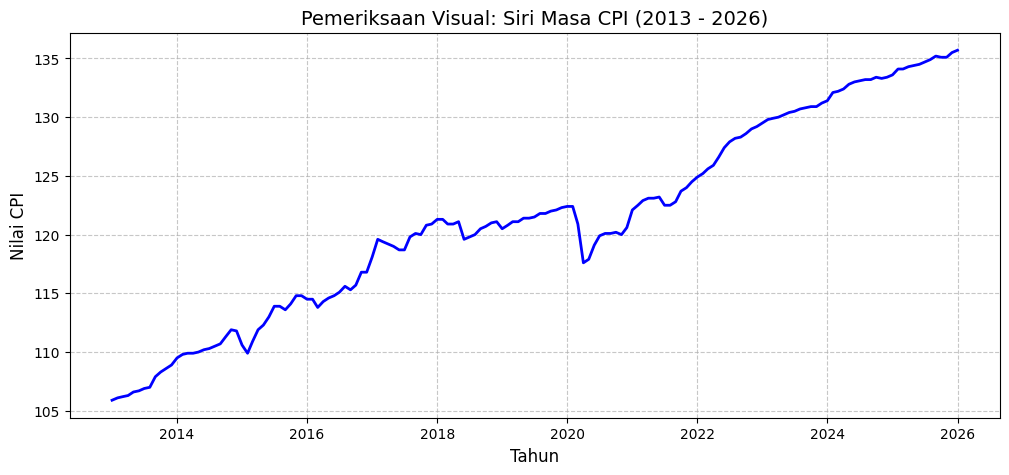

In [11]:
#Plot data asal untuk menyemak varians
plt.figure(figsize=(12, 5))
plt.plot(df_data.index, df_data['CPI_Index'], color='blue', linewidth=2)
plt.title('Pemeriksaan Visual: Siri Masa CPI (2013 - 2026)', fontsize=14)
plt.xlabel('Tahun', fontsize=12)
plt.ylabel('Nilai CPI', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Tidak perlu buat transformasi log kerana saiz "zig-zag" agak konsisten.
Oleh itu, varians siri masa CPI dianggap stabil secara semula jadi kejatuhan mendadak (titik terendah selepas trend menaik) berlaku tepat pada awal tahun 2020. Ini bertepatan dengan permulaan pandemik COVID-19 dan pelaksanaan Perintah Kawalan Pergerakan (PKP) di Malaysia yang menjejaskan rantaian bekalan dan perbelanjaan pengguna.

###**UJIAN KEPEGUNAN**

In [12]:
from statsmodels.tsa.stattools import kpss
import warnings

# Abaikan amaran kpss untuk output terminal yang bersih
warnings.filterwarnings("ignore")

def semak_kpss(siri_masa, nama_kolum):
    print(f"--- Ujian KPSS untuk {nama_kolum} ---")
    # Menjalankan ujian KPSS
    kpss_stat, p_value, lags, crit_dict = kpss(siri_masa.dropna(), regression='c')

    print(f'Nilai Statistik KPSS : {kpss_stat:.4f}')
    print(f'Nilai p (p-value)    : {p_value:.4f}')

    if p_value < 0.05:
        print("Keputusan: Tidak Pegun (Tolak H0) -> PERLU TRANSFORMASI PEMBEZAAN\n")
        return False
    else:
        print("Keputusan: Pegun (Gagal Tolak H0) -> SELAMAT (TIDAK PERLU PEMBEZAAN)\n")
        return True

# 1. Uji CPI Asal
pegun_asal = semak_kpss(df_data['CPI_Index'], 'CPI Asal')

# 2. Jika Tidak Pegun, buat pembezaan (differencing) dan uji semula
if not pegun_asal:
    df_data['CPI_diff'] = df_data['CPI_Index'].diff()
    print("--- Menguji Selepas Pembezaan Pertama ---")
    semak_kpss(df_data['CPI_diff'], 'CPI (Selepas Pembezaan)')

--- Ujian KPSS untuk CPI Asal ---
Nilai Statistik KPSS : 1.7615
Nilai p (p-value)    : 0.0100
Keputusan: Tidak Pegun (Tolak H0) -> PERLU TRANSFORMASI PEMBEZAAN

--- Menguji Selepas Pembezaan Pertama ---
--- Ujian KPSS untuk CPI (Selepas Pembezaan) ---
Nilai Statistik KPSS : 0.0649
Nilai p (p-value)    : 0.1000
Keputusan: Pegun (Gagal Tolak H0) -> SELAMAT (TIDAK PERLU PEMBEZAAN)



Siri masa CPI anda adalah bersepadu pada tahap satu. Ini memberikan justifikasi teori yang sangat kukuh mengapa anda wajib menggunakan siri masa yang telah dibezakan (CPI_diff) untuk model-model garis dasar statistik kelak.

###**UJIAN KORELASI**

In [13]:
import pandas as pd

# 1. Kira matriks korelasi Pearson untuk semua pembolehubah berangka
korelasi_asas = df_data.corr(numeric_only=True)

# 2. Ambil nilai korelasi terhadap CPI sahaja dan buang korelasi CPI dengan dirinya sendiri
korelasi_cpi = korelasi_asas['CPI_Index'].drop('CPI_Index')

# 3. Tukar kepada struktur DataFrame untuk manipulasi dan paparan yang kemas
df_korelasi = korelasi_cpi.to_frame(name='Nilai Korelasi')

# 4. Tambah nilai absolut (mutlak) untuk memudahkan susunan tanpa mengira arah positif/negatif
df_korelasi['Kekuatan Mutlak'] = df_korelasi['Nilai Korelasi'].abs()

# 5. Susun data secara MENURUN bermula daripada yang paling kuat
df_korelasi_tersusun = df_korelasi.sort_values(by='Kekuatan Mutlak', ascending=False)

# 6. Fungsi pengkategorian laras bahasa akademik
def kategori_korelasi(nilai):
    abs_val = abs(nilai)
    if abs_val >= 0.7:
        return 'Kuat'
    elif abs_val >= 0.4:
        return 'Sederhana'
    else:
        return 'Lemah'

# Terapkan pengkategorian
df_korelasi_tersusun['Kategori'] = df_korelasi_tersusun['Nilai Korelasi'].apply(kategori_korelasi)

# Buang kolum rujukan (Kekuatan Mutlak) untuk hasil paparan yang bersih
df_korelasi_tersusun = df_korelasi_tersusun.drop(columns=['Kekuatan Mutlak'])

print("--- Keputusan Analisis Korelasi Pemacu Inflasi (Susunan Menurun) ---")
print(df_korelasi_tersusun)

--- Keputusan Analisis Korelasi Pemacu Inflasi (Susunan Menurun) ---
                   Nilai Korelasi   Kategori
Year                     0.976846       Kuat
M3_Total                 0.973251       Kuat
USD_Avg                  0.799904       Kuat
PPI_Index                0.672522  Sederhana
OPR_Rate                -0.234034      Lemah
Unemployment_Rate        0.098299      Lemah
Month                    0.058317      Lemah
CPI_diff                 0.008798      Lemah


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

In [16]:
# 1. Buat pengiraan matriks korelasi yang betul (Tanpa CPI_Index)
df_bersih = df_data.drop(columns=['Year', 'Month', 'CPI_Index'])
korelasi_asas = df_bersih.corr(numeric_only=True)

In [17]:
# 2. Cetak jadual
print("\n--- MATRIKS KORELASI PEMACU INFLASI ---")
print(korelasi_asas.round(4))


--- MATRIKS KORELASI PEMACU INFLASI ---
                   USD_Avg  M3_Total  OPR_Rate  PPI_Index  Unemployment_Rate  CPI_diff
USD_Avg             1.0000    0.7389   -0.2034     0.3552             0.2999   -0.0262
M3_Total            0.7389    1.0000   -0.3673     0.6897             0.2034   -0.0163
OPR_Rate           -0.2034   -0.3673    1.0000    -0.2361            -0.8439   -0.0983
PPI_Index           0.3552    0.6897   -0.2361     1.0000            -0.0950    0.1333
Unemployment_Rate   0.2999    0.2034   -0.8439    -0.0950             1.0000   -0.0418
CPI_diff           -0.0262   -0.0163   -0.0983     0.1333            -0.0418    1.0000


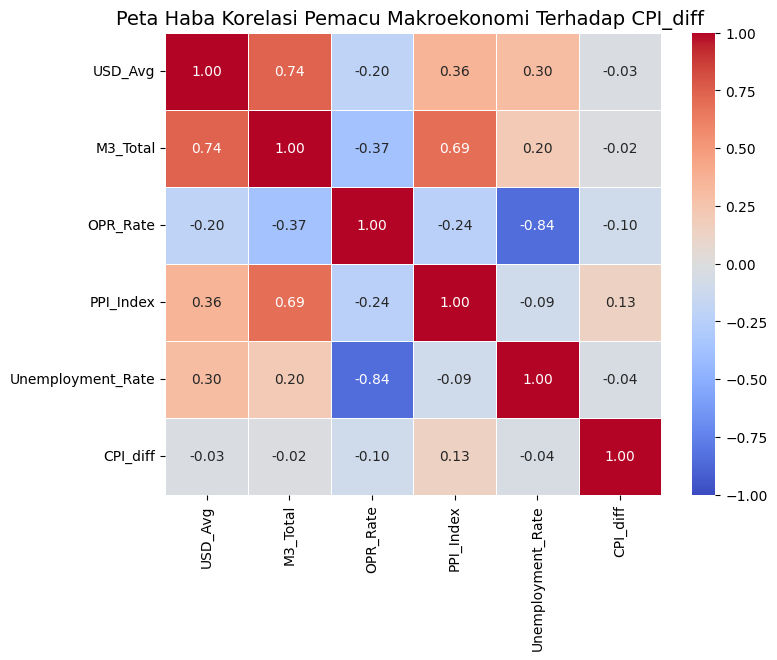

In [18]:
# 4. Plot Peta Haba (Heatmap)
plt.figure(figsize=(8, 6)) # Saiz yang lebih kemas
sns.heatmap(korelasi_asas,
            annot=True,              # Tunjukkan nombor
            cmap='coolwarm',         # Skema warna (merah/biru)
            fmt=".2f",               # 2 titik perpuluhan
            linewidths=0.5,          # Garisan pemisah
            vmin=-1, vmax=1)

plt.title('Peta Haba Korelasi Pemacu Makroekonomi Terhadap CPI_diff ', fontsize=14)
plt.show()

###**UJIAN MULTIKOLINEARITI**

In [19]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [20]:
#1. Pilih pemboleh ubah tidak bersandar
X = df_data[['M3_Total', 'USD_Avg', 'PPI_Index', 'OPR_Rate', 'Unemployment_Rate']]

In [21]:
#2. Tambah pemalar (constant) - Langkah ekonometrik yang wajib untuk VIF
X_dengan_pemalar = sm.add_constant(X)

Mengapa perlu add sm.add_constant : Dalam ekonometrik, model OLS (seperti model garis dasar statistik yang akan anda gunakan nanti) memerlukan titik pintasan paksi-Y (Y-intercept). Pustaka statsmodels sangat ketat dan tidak akan memasukkan pemalar ini secara automatik. Jika kita tidak mengolah data dengan menambah pemalar tersebut sebelum ujian VIF, nilai $R^2$ yang dikira akan menjadi ralat dan memberikan nilai VIF yang palsu.

In [22]:
# 3. Bina DataFrame untuk menyimpan keputusan
vif_data = pd.DataFrame()
vif_data["Pemacu Ekonomi"] = X_dengan_pemalar.columns

In [23]:
# 4. Kira nilai VIF untuk setiap pembolehubah
vif_data["Nilai VIF"] = [variance_inflation_factor(X_dengan_pemalar.values, i)
                          for i in range(X_dengan_pemalar.shape[1])]

In [24]:
# 5. Buang baris 'const' (pemalar) untuk paparan yang bersih
vif_data = vif_data[vif_data['Pemacu Ekonomi'] != 'const']

In [25]:
# 6. Susun mengikut Nilai VIF tertinggi untuk mudah dianalisis
vif_data = vif_data.sort_values(by='Nilai VIF', ascending=False)

In [26]:
# 7. Paparkan keputusan dengan kemas
print("\n" + "="*45)
print(" UJIAN MULTIKOLINEARITI (VIF) ".center(45))
print("="*45)
print(vif_data.to_string(index=False))
print("="*45)


         UJIAN MULTIKOLINEARITI (VIF)        
   Pemacu Ekonomi  Nilai VIF
Unemployment_Rate   7.665368
         OPR_Rate   7.536970
         M3_Total   4.696190
          USD_Avg   3.475122
        PPI_Index   2.879476


(VIF < 5): M3_Total, USD_Avg, dan PPI_Index berada pada tahap yang sangat sempurna. Ia langsung tidak bertindih fungsi secara melampau antara satu sama lain.

(VIF 5 - 10): Unemployment_Rate (7.66) dan OPR_Rate (7.53) menunjukkan multikolineariti tahap sederhana.

Adalah sangat normal dan logik untuk Pengangguran dan OPR mempunyai sedikit perkaitan. Mengikut teori ekonomi makro, Bank Negara Malaysia (BNM) sering menyesuaikan kadar OPR berdasarkan keadaan pasaran buruh (pengangguran) untuk mengawal inflasi.

Disesbabkan semua nilai VIF < 10 , maka tidak perlu membuang mana-mana pemboleh ubah

###**PEMBAHAGIAN DATA - LATIHAN DAN UJIAN**

In [27]:
df_data.head()

,Year,Month,CPI_Index,USD_Avg,M3_Total,OPR_Rate,PPI_Index,Unemployment_Rate,CPI_diff
Date,,,,,,,,,
2013-01-01,2013,1,105.9,3.0390,1375858.0,3.0,107.9,3.4,NaN
2013-02-01,2013,2,106.1,3.0978,1379389.6,3.0,109.6,3.0,0.2
2013-03-01,2013,3,106.2,3.1076,1392122.9,3.0,108.2,3.2,0.1
2013-04-01,2013,4,106.3,3.0498,1399798.9,3.0,107.3,3.0,0.1
2013-05-01,2013,5,106.6,3.0168,1414632.1,3.0,106.6,3.2,0.3


In [28]:
# 1. Buang baris pertama yang mempunyai 'NaN' (akibat proses differencing CPI_diff tadi)
df_bersih = df_data.dropna().copy()

In [29]:
# 2. Tetapkan pembolehubah X dan Y
pembolehubah_x = ['OPR_Rate', 'PPI_Index', 'Unemployment_Rate', 'M3_Total', 'USD_Avg']
X = df_bersih[pembolehubah_x]
y_diff = df_bersih['CPI_diff']
y_asal = df_bersih['CPI_Index']

In [30]:
# 3. Potong data 80/20 secara kronologi
saiz_latihan = int(len(df_bersih) * 0.8)

In [31]:
# Pembahagian X (Tanpa Constant - Akan digunakan untuk Machine Learning)
X_latih = X.iloc[:saiz_latihan]
X_uji = X.iloc[saiz_latihan:]

In [32]:
# Pembahagian Y (Latihan guna CPI_diff, Ujian guna jawapan CPI_Index sebenar)
y_latih_diff = y_diff.iloc[:saiz_latihan]
y_latih_asal = y_asal.iloc[:saiz_latihan]
y_uji_asal = y_asal.iloc[saiz_latihan:]

In [33]:
# 4. Nilai 'CPI Semalam' sedia ada untuk tujuan transformasi songsang nanti
cpi_semalam = df_bersih['CPI_Index'].iloc[saiz_latihan - 1 : len(df_bersih) - 1].values

In [34]:
# Paparkan ringkasan pembahagian untuk rujukan tesis
print(f"--- RINGKASAN PEMBAHAGIAN DATA (80/20) ---")
print(f"Jumlah keseluruhan bulan : {len(df_bersih)} bulan")
print(f"Data Latihan (80%)       : {len(X_latih)} bulan (Dari {X_latih.index[0].date()} hingga {X_latih.index[-1].date()})")
print(f"Data Ujian (20%)         : {len(X_uji)} bulan (Dari {X_uji.index[0].date()} hingga {X_uji.index[-1].date()})")

--- RINGKASAN PEMBAHAGIAN DATA (80/20) ---
Jumlah keseluruhan bulan : 156 bulan
Data Latihan (80%)       : 124 bulan (Dari 2013-02-01 hingga 2023-05-01)
Data Ujian (20%)         : 32 bulan (Dari 2023-06-01 hingga 2026-01-01)


###**MODEL OLS**

In [35]:
import statsmodels.api as sm

In [36]:
# 1. Tambah pemalar (Y-intercept) kepada data latihan dan data ujian
X_latih_ols = sm.add_constant(X_latih)
X_uji_ols = sm.add_constant(X_uji)

Sama seperti ujian VIF tadi, kita wajib menambah pemalar (constant) kepada data latihan X_latih supaya garisan regresi tidak dipaksa bermula dari titik sifar (0,0).

In [37]:
#2. Inisialisasi dan Latih Model OLS
model_ols = sm.OLS(y_latih_diff, X_latih_ols)
keputusan_ols = model_ols.fit()

In [38]:
# 3. Paparkan Ringkasan Penuh OLS
print(keputusan_ols.summary())

                            OLS Regression Results                            
Dep. Variable:               CPI_diff   R-squared:                       0.116
Model:                            OLS   Adj. R-squared:                  0.078
Method:                 Least Squares   F-statistic:                     3.090
Date:                Sun, 07 Jun 2026   Prob (F-statistic):             0.0117
Time:                        14:51:59   Log-Likelihood:                -97.468
No. Observations:                 124   AIC:                             206.9
Df Residuals:                     118   BIC:                             223.9
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 3.8912      2.53

1. Ujian F menunjukkan model regresi adalah signifikan secara keseluruhan pada aras keertian 5% (p < 0.05), membuktikan pembolehubah makroekonomi yang dipilih mempunyai keupayaan menerangkan perubahan CPI.
2. Ujian Jarque-Bera menunjukkan sisa ralat tidak tertabur secara normal (p < 0.05). Walau bagaimanapun, mengikut Teorem Had Memusat (CLT), kekangan ini boleh dilonggarkan memandangkan jumlah pemerhatian kajian melebihi 100 sampel (N=124).
3. Nilai Durbin-Watson sebanyak 1.465 (kurang daripada 2.0) mengesahkan kehadiran masalah autokorelasi positif dalam sisa ralat model OLS.

###**RAMALAN & UJIAN DATA UNTUK OLS**

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, mean_absolute_error , r2_score

In [40]:
# 1. Ramalan & Transformasi Songsang
ramalan_ols_diff = keputusan_ols.predict(X_uji_ols)
ramalan_ols_index = pd.Series(cpi_semalam + ramalan_ols_diff.values, index=y_uji_asal.index)

In [41]:
# 2. Kira Ralat
r2_ols = r2_score(y_uji_asal, ramalan_ols_index)
mae_ols = mean_absolute_error(y_uji_asal, ramalan_ols_index)
rmse_ols = np.sqrt(mean_squared_error(y_uji_asal, ramalan_ols_index))

In [42]:
# 8. Papar hasil penilaian ralat
print("\n" + "="*45)
print(" PRESTASI RAMALAN OLS (INDEKS CPI) ".center(45))
print("="*45)
print(f" Nilai R-Squared (R2) : {r2_ols:.4f}")
print(f" Nilai MAE  : {mae_ols:.4f}")
print(f" Nilai RMSE : {rmse_ols:.4f}")
print("="*45 + "\n")


      PRESTASI RAMALAN OLS (INDEKS CPI)      
 Nilai R-Squared (R2) : 0.9838
 Nilai MAE  : 0.1557
 Nilai RMSE : 0.2037



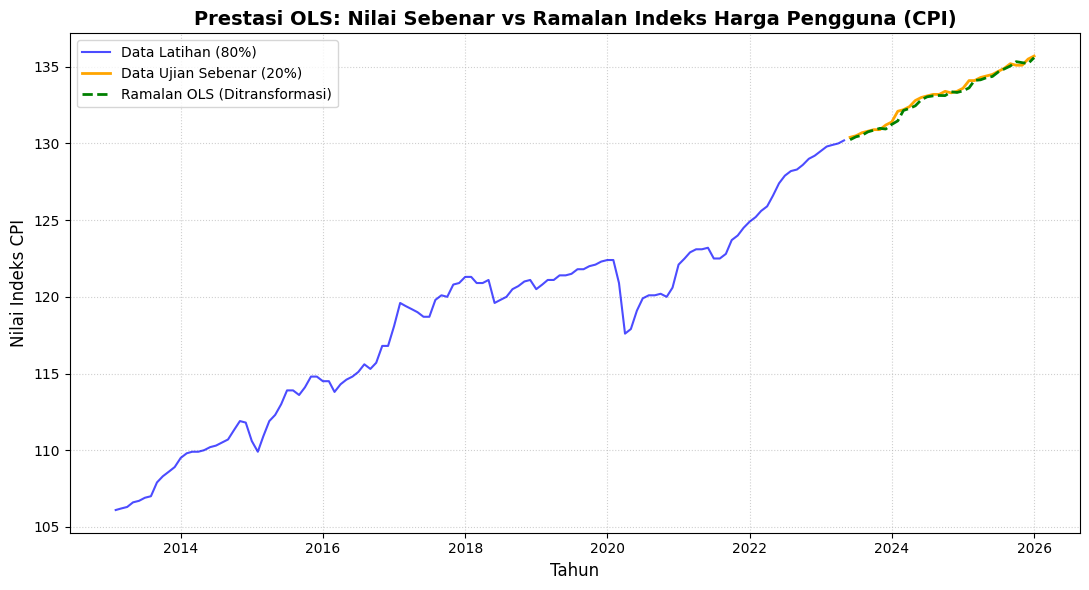

In [43]:
# 9. Plot Graf Perbandingan
plt.figure(figsize=(11, 6))

plt.plot(y_latih_asal, label='Data Latihan (80%)', color='blue', alpha=0.7)
plt.plot(y_uji_asal, label='Data Ujian Sebenar (20%)', color='orange', linewidth=2)
plt.plot(ramalan_ols_index, label='Ramalan OLS (Ditransformasi)', color='green', linestyle='--', linewidth=2)

plt.title('Prestasi OLS: Nilai Sebenar vs Ramalan Indeks Harga Pengguna (CPI)', fontsize=14, fontweight='bold')
plt.xlabel('Tahun', fontsize=12)
plt.ylabel('Nilai Indeks CPI', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

Walaupun jadual perbandingan menunjukkan model OLS mencatatkan ralat MAE (0.1557) yang lebih rendah berbanding ARIMA (2.8542), perbandingan langsung ini perlu ditafsir dengan berhati-hati. Prestasi OLS dipacu oleh struktur unjuran 'satu langkah ke hadapan' (one-step-ahead forecast) yang memanfaatkan nilai indeks sebenar pada tempoh t-1 untuk transformasi. Manakala ARIMA dinilai berdasarkan unjuran dinamik pelbagai langkah (multi-step dynamic forecast) yang lebih mencabar secara empirikal. Walau bagaimanapun, kedua-dua model garis dasar ini berjaya menetapkan penanda aras ralat yang munasabah untuk kajian ini.

###**ARIMA**

In [44]:
import itertools
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA

In [45]:
# 1. Tetapkan julat parameter (0 hingga 2) dan kekalkan d=1
p_julat = range(0, 3)
d_julat = [1]  # Tetap pada 1 berpandukan hasil Ujian KPSS sebelum ini
q_julat = range(0, 3)

In [46]:
kombinasi_pdq = list(itertools.product(p_julat, d_julat, q_julat))

terbaik_aic = float("inf")
terbaik_order = None

In [47]:
print("--- 1. MENJALANKAN CARIAN GRID ARIMA ---")

# 3. Gelung pengiraan untuk menguji setiap model
for order in kombinasi_pdq:
    try:
        model = ARIMA(y_latih_asal, order=order)
        hasil = model.fit()
        print(f"Menguji Kombinasi ARIMA{order} -> AIC: {hasil.aic:.3f}")

        # Kemas kini jika menjumpai nilai AIC yang lebih rendah
        if hasil.aic < terbaik_aic:
            terbaik_aic = hasil.aic
            terbaik_order = order
    except:
        continue

--- 1. MENJALANKAN CARIAN GRID ARIMA ---
Menguji Kombinasi ARIMA(0, 1, 0) -> AIC: 225.368
Menguji Kombinasi ARIMA(0, 1, 1) -> AIC: 203.728
Menguji Kombinasi ARIMA(0, 1, 2) -> AIC: 205.642
Menguji Kombinasi ARIMA(1, 1, 0) -> AIC: 209.098
Menguji Kombinasi ARIMA(1, 1, 1) -> AIC: 205.638
Menguji Kombinasi ARIMA(1, 1, 2) -> AIC: 207.633
Menguji Kombinasi ARIMA(2, 1, 0) -> AIC: 207.345
Menguji Kombinasi ARIMA(2, 1, 1) -> AIC: 207.628
Menguji Kombinasi ARIMA(2, 1, 2) -> AIC: 204.224


In [48]:
print("\n" + "="*45)
print(f" MODEL TERBAIK DIPILIH: ARIMA{terbaik_order}".center(45))
print(f" NILAI AIC TERENDAH: {terbaik_aic:.3f}".center(45))
print("="*45 + "\n")


     MODEL TERBAIK DIPILIH: ARIMA(0, 1, 1)   
          NILAI AIC TERENDAH: 203.728        



In [49]:
# 4. Melatih model akhir menggunakan parameter optimum yang ditemui
print("--- 2. MELATIH MODEL ARIMA OPTIMUM ---")
model_arima_terbaik = ARIMA(y_latih_asal, order=terbaik_order)
keputusan_arima = model_arima_terbaik.fit()
print(keputusan_arima.summary())

--- 2. MELATIH MODEL ARIMA OPTIMUM ---
                               SARIMAX Results                                
Dep. Variable:              CPI_Index   No. Observations:                  124
Model:                 ARIMA(0, 1, 1)   Log Likelihood                 -99.864
Date:                Sun, 07 Jun 2026   AIC                            203.728
Time:                        14:52:04   BIC                            209.352
Sample:                    02-01-2013   HQIC                           206.013
                         - 05-01-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.4722      0.055      8.645      0.000       0.365       0.579
sigma2         0.2964      0.023     12.821      0.000       0.251       0.342
Ljung-Box (L1

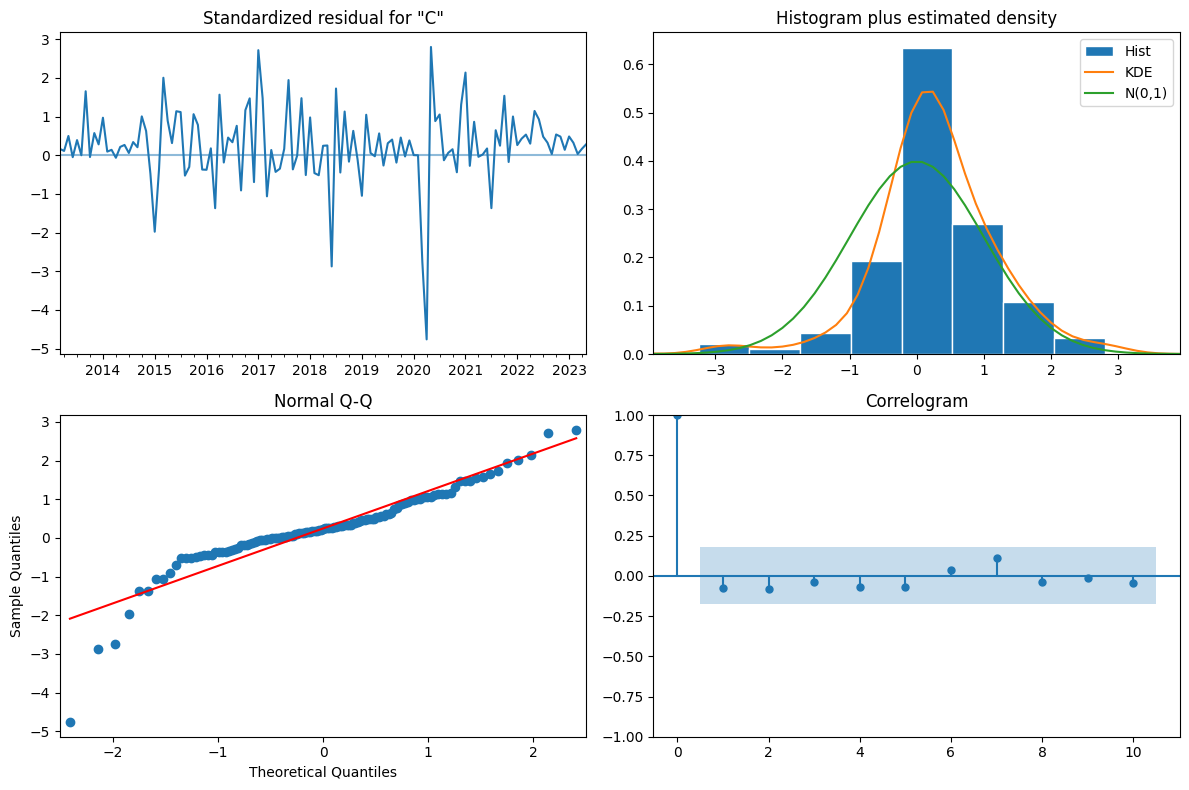

In [50]:
import matplotlib.pyplot as plt

# Memanggil fungsi plot diagnostik terus daripada hasil model statsmodels anda
fig = keputusan_arima.plot_diagnostics(figsize=(12, 8))

# Memperkemas ruang supaya graf tidak bertindih
plt.tight_layout()
plt.show()

###**RAMALAN & UJIAN DATA UNTUK ARIMA**

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.tsa.arima.model import ARIMA

In [52]:
# 1. Ramalan (Terus dalam CPI_Index, tiada transformasi songsang diperlukan)
ramalan_arima = keputusan_arima.forecast(steps=len(y_uji_asal))
ramalan_arima.index = y_uji_asal.index

In [53]:
# 2. Kira Ralat
r2_arima = r2_score(y_uji_asal, ramalan_arima)
mae_arima = mean_absolute_error(y_uji_asal, ramalan_arima)
rmse_arima = np.sqrt(mean_squared_error(y_uji_asal, ramalan_arima))

In [54]:
# 6. Paparan Keputusan Rasmi
print("\n" + "="*45)
print(f" PRESTASI RAMALAN ARIMA{terbaik_order} ".center(45))
print("="*45)
print(f" Nilai R-Squared (R2) : {r2_arima:.4f}")
print(f" Nilai MAE            : {mae_arima:.4f}")
print(f" Nilai RMSE           : {rmse_arima:.4f}")
print("="*45 + "\n")


       PRESTASI RAMALAN ARIMA(0, 1, 1)       
 Nilai R-Squared (R2) : -3.1804
 Nilai MAE            : 2.8542
 Nilai RMSE           : 3.2723



Model ARIMA(0,1,1) mencatatkan nilai $R^2$ yang negatif (-3.1804). Hal ini adalah satu kelaziman dalam pemodelan siri masa luar sampel (out-of-sample) kerana $R^2$ mengukur varians yang dijelaskan, yang sering gagal menangkap anjakan struktur (structural shifts) jangka panjang tanpa sokongan pembolehubah luaran.

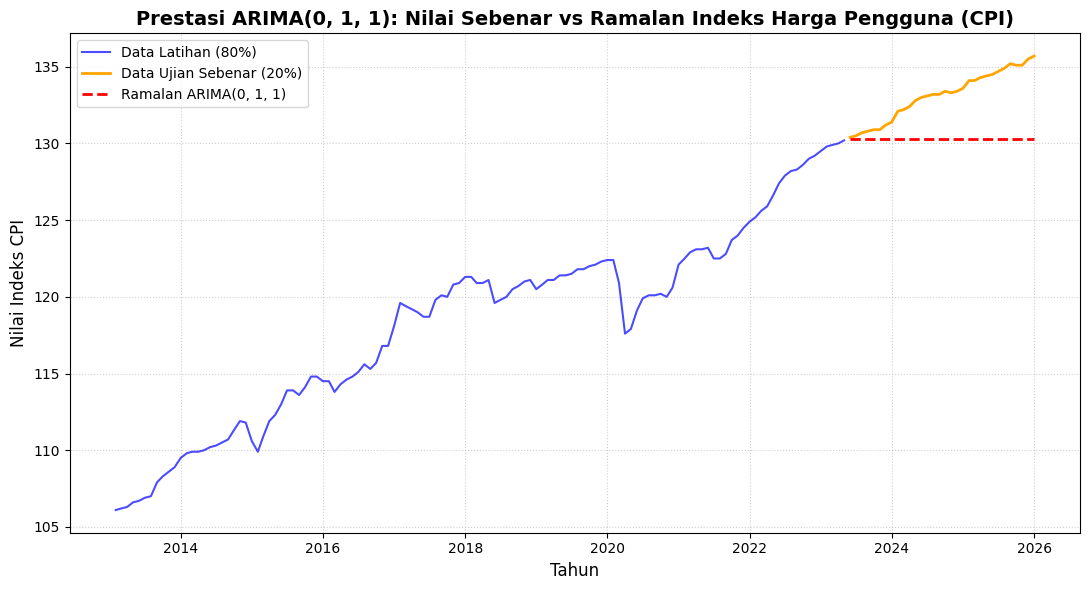

In [55]:
# 7. Plot Graf Perbandingan
plt.figure(figsize=(11, 6))

plt.plot(y_latih_asal, label='Data Latihan (80%)', color='blue', alpha=0.7)
plt.plot(y_uji_asal, label='Data Ujian Sebenar (20%)', color='orange', linewidth=2)
plt.plot(ramalan_arima, label=f'Ramalan ARIMA{terbaik_order}', color='red', linestyle='--', linewidth=2)

plt.title(f'Prestasi ARIMA{terbaik_order}: Nilai Sebenar vs Ramalan Indeks Harga Pengguna (CPI)', fontsize=14, fontweight='bold')
plt.xlabel('Tahun', fontsize=12)
plt.ylabel('Nilai Indeks CPI', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

Berdasarkan carian grid sebelum ini, kombinasi pemenang bagi siri masa ini ialah ARIMA(0, 1, 1). Oleh kerana komponen Autoregressive ialah $p=0$, model ini tidak mempunyai "ingatan" jangka panjang daripada data sejarah. Komponen Moving Average pula hanya $q=1$, bermaksud kapasiti ralatnya terpadam selepas 1 bulan sahaja.

Penilaian model garis dasar mendedahkan kelemahan kritikal pada algoritma tradisional; ARIMA(0,1,1) gagal menangkap trend dinamik masa hadapan yang kompleks (hanya menghasilkan unjuran mendatar), manakala ketepatan luar biasa OLS adalah ilusi yang terikat dengan kebergantungan kepada data sejarah jangka pendek secara langsung. Kelemahan ini menjustifikasikan keperluan empirikal untuk kajian ini mengeksploitasi seni bina Pembelajaran Mesin yang lebih teguh.

###**LASSO REGRESSION**

In [56]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [57]:
# 1. Piawaikan data
scaler_lr = StandardScaler()
X_latih_skala_lr = scaler_lr.fit_transform(X_latih)
X_uji_skala_lr = scaler_lr.transform(X_uji)

In [58]:
# 2. MENGOLAH MODEL MELALUI GRIDSEARCHCV
lasso_asas = Lasso(random_state=42)

In [59]:
# 3. Menguji pelbagai nilai penalti alpha
parameter_grid_lr = {'alpha': [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0]}
grid_search_lr = GridSearchCV(lasso_asas, parameter_grid_lr, cv=5, scoring='neg_mean_absolute_error')

In [60]:
# 4. Latih model menggunakan data sasaran CPI_diff
grid_search_lr.fit(X_latih_skala_lr, y_latih_diff)

GridSearchCV(cv=5, estimator=Lasso(random_state=42),
             param_grid={'alpha': [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0]},
             scoring='neg_mean_absolute_error')

In [61]:
model_lasso_terbaik = grid_search_lr.best_estimator_
print(f"Nilai Alpha Pemenang Ditemui: {model_lasso_terbaik.alpha}")

Nilai Alpha Pemenang Ditemui: 1.0


###**RAMALAN & UJIAN DATA LASSO REGRESSION**

In [62]:
# 1. Ramalan
ramalan_lr_diff = model_lasso_terbaik.predict(X_uji_skala_lr)

In [63]:
# 2. Transformasi data
ramalan_lr_index = cpi_semalam + ramalan_lr_diff
ramalan_lr_index = pd.Series(ramalan_lr_index, index=y_uji_asal.index)

In [64]:
# 3. Penilaian prestasi (MAE, RMSE, R2)
r2_lr = r2_score(y_uji_asal, ramalan_lr_index)
mae_lr = mean_absolute_error(y_uji_asal, ramalan_lr_index)
rmse_lr = np.sqrt(mean_squared_error(y_uji_asal, ramalan_lr_index))

In [65]:
# 4. Papar keputusan rasmi
print("\n" + "="*45)
print(" PRESTASI RAMALAN LASSO REGRESSION ".center(45))
print("="*45)
print(f" Nilai R-Squared (R2) : {r2_lr:.4f}")
print(f" Nilai MAE  : {mae_lr:.4f}")
print(f" Nilai RMSE : {rmse_lr:.4f}")
print("="*45 + "\n")


      PRESTASI RAMALAN LASSO REGRESSION      
 Nilai R-Squared (R2) : 0.9895
 Nilai MAE  : 0.1159
 Nilai RMSE : 0.1642



In [66]:
# 5. Semakan pengeluaran ciri
print("--- KEPUTUSAN PENYINGKIRAN CIRI (PEKALI LASSO) ---")
pekali_df = pd.DataFrame({
    'Pembolehubah': pembolehubah_x,
    'Pekali': model_lasso_terbaik.coef_
})
# Susun dari nilai paling kuat kepada paling lemah/sifar
pekali_df['Mutlak'] = pekali_df['Pekali'].abs()
pekali_df = pekali_df.sort_values(by='Mutlak', ascending=False).drop('Mutlak', axis=1)
print(pekali_df.to_string(index=False))

--- KEPUTUSAN PENYINGKIRAN CIRI (PEKALI LASSO) ---
     Pembolehubah  Pekali
         OPR_Rate    -0.0
        PPI_Index     0.0
Unemployment_Rate    -0.0
         M3_Total    -0.0
          USD_Avg    -0.0


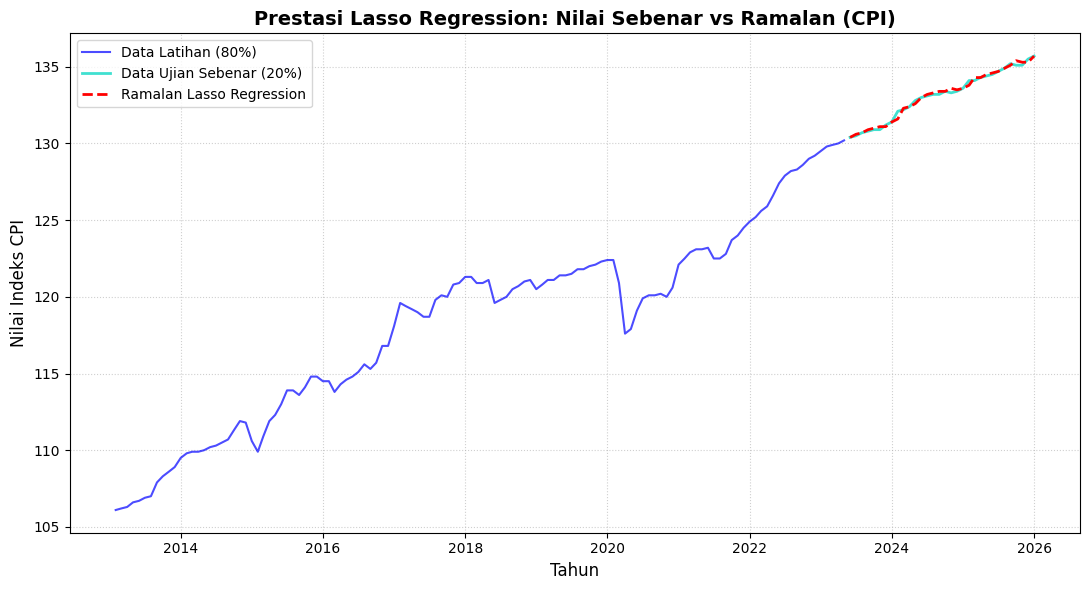

In [67]:
# 6. Plot graf perbandingan
plt.figure(figsize=(11, 6))

plt.plot(y_latih_asal, label='Data Latihan (80%)', color='blue', alpha=0.7)
plt.plot(y_uji_asal, label='Data Ujian Sebenar (20%)', color='turquoise', linewidth=2)
plt.plot(ramalan_lr_index, label='Ramalan Lasso Regression', color='red', linestyle='--', linewidth=2)

plt.title('Prestasi Lasso Regression: Nilai Sebenar vs Ramalan (CPI)', fontsize=14, fontweight='bold')
plt.xlabel('Tahun', fontsize=12)
plt.ylabel('Nilai Indeks CPI', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

ika kita membandingkan prestasi secara langsung, model OLS mencatatkan nilai ralat MAE sebanyak 0.1557 dengan bergantung kepada kesemua lima pembolehubah makroekonomi secara serentak. Walau bagaimanapun, apa yang sangat mengejutkan secara empirikal ialah model Lasso berjaya mencatatkan ralat yang lebih rendah dan cemerlang (0.1159), walaupun algoritma tersebut telah mengecutkan kesemua pembolehubah makroekonomi menjadi sifar (0.0).

Analisis perbandingan mendedahkan bahawa model linear (OLS dan Lasso Regression) telah menemui batasan teknikal, di mana algoritma tersebut gagal mengekstrak corak ramalan yang bermakna, sekaligus memaksa model bergantung kepada nilai malar (pintasan) semata-mata untuk mengurangkan ralat. Kebuntuan pemodelan linear ini secara empirikal memberikan justifikasi akademik yang utuh untuk metodologi ini beralih ke fasa seterusnya.

###**RANDOM FOREST**

In [148]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFECV
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [149]:
# 1. Piawaikan data
scaler_rf = StandardScaler()
X_latih_skala_rf = scaler_rf.fit_transform(X_latih)
X_uji_skala_rf = scaler_rf.transform(X_uji)

In [150]:
# 2.  Menapis data untuk RECURSIVE FEATURE ELIMINATION (RFE)
rf_rfe = RandomForestRegressor(random_state=42)

In [151]:
# 3. Menggunakan RFECV untuk membuang ciri yang tidak relevan secara saintifik
penapis_rfe = RFECV(estimator=rf_rfe, step=1, cv=5, scoring='neg_mean_absolute_error')
penapis_rfe.fit(X_latih_skala_rf, y_latih_diff)

RFECV(cv=5, estimator=RandomForestRegressor(random_state=42),
      scoring='neg_mean_absolute_error')

In [152]:
# 4. Mengekstrak pembolehubah makroekonomi yang melepasi tapisan RFE
pembolehubah_terpilih = np.array(pembolehubah_x)[penapis_rfe.support_]
print(f"Pembolehubah Terselamat (Lulus RFE): {pembolehubah_terpilih}")

Pembolehubah Terselamat (Lulus RFE): ['PPI_Index' 'Unemployment_Rate']


In [153]:
# 5. Memperkemas X dengan HANYA menggunakan ciri-ciri yang telah lulus tapisan RFE
X_latih_rfe = penapis_rfe.transform(X_latih_skala_rf)
X_uji_rfe = penapis_rfe.transform(X_uji_skala_rf)

In [154]:
# 6. Mencari model RF terbaik
rf_asas = RandomForestRegressor(random_state=42)
parameter_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]}

grid_search_rf = GridSearchCV(rf_asas, parameter_grid_rf, cv=5, scoring='neg_mean_absolute_error')
grid_search_rf.fit(X_latih_rfe, y_latih_diff)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
             param_grid={'max_depth': [None, 5, 10],
                         'min_samples_split': [2, 5],
                         'n_estimators': [50, 100, 200]},
             scoring='neg_mean_absolute_error')

In [155]:
# 7. Model terbaik
model_rf_terbaik = grid_search_rf.best_estimator_
print(f"Kombinasi Parameter Pemenang: {grid_search_rf.best_params_}")

Kombinasi Parameter Pemenang: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}


###**RAMALAN & UJIAN DATA RANDOM FOREST**

In [156]:
# 1. JJana ramalan dan melakukan transformasi songsang
ramalan_rf_diff = model_rf_terbaik.predict(X_uji_rfe)
ramalan_rf_index = cpi_semalam + ramalan_rf_diff
ramalan_rf_index = pd.Series(ramalan_rf_index, index=y_uji_asal.index)

In [157]:
# 2. PENILAIAN PRESTASI (MAE, RMSE, R2)
r2_rf = r2_score(y_uji_asal, ramalan_rf_index)
mae_rf = mean_absolute_error(y_uji_asal, ramalan_rf_index)
rmse_rf = np.sqrt(mean_squared_error(y_uji_asal, ramalan_rf_index))

In [158]:
# 3. Papar keputusan akhir
print("\n" + "="*45)
print(" PRESTASI RAMALAN RANDOM FOREST ".center(45))
print("="*45)
print(f" Nilai R-Squared (R2) : {r2_rf:.4f}")
print(f" Nilai MAE  : {mae_rf:.4f}")
print(f" Nilai RMSE : {rmse_rf:.4f}")
print("="*45 + "\n")


        PRESTASI RAMALAN RANDOM FOREST       
 Nilai R-Squared (R2) : 0.9839
 Nilai MAE  : 0.1760
 Nilai RMSE : 0.2029



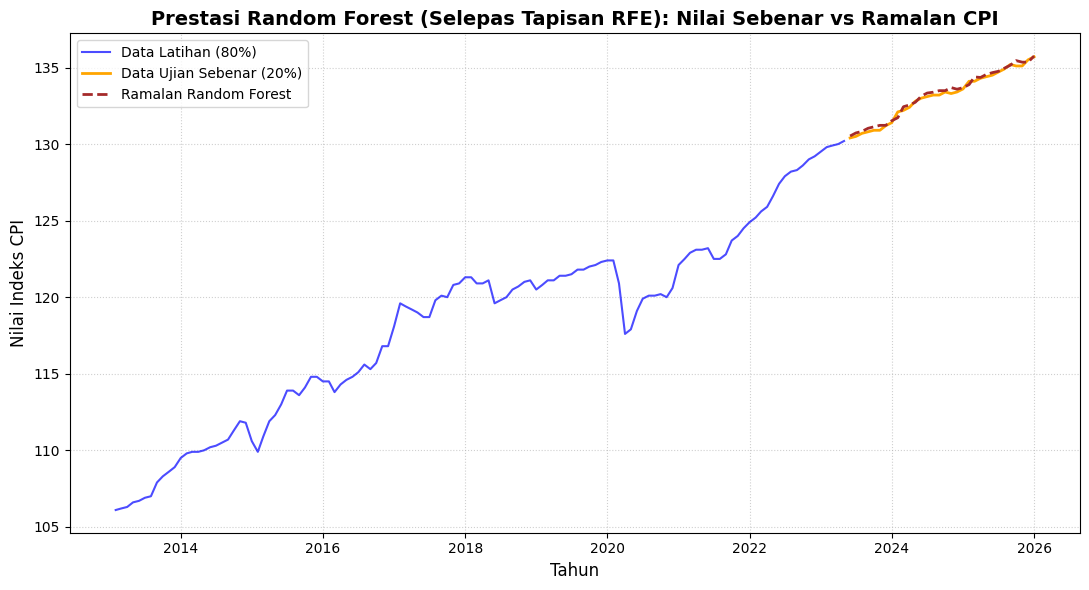

In [159]:
# 6. Plot graf perbandingan
plt.figure(figsize=(11, 6))

plt.plot(y_latih_asal, label='Data Latihan (80%)', color='blue', alpha=0.7)
plt.plot(y_uji_asal, label='Data Ujian Sebenar (20%)', color='orange', linewidth=2)
plt.plot(ramalan_rf_index, label='Ramalan Random Forest', color='brown', linestyle='--', linewidth=2)

plt.title('Prestasi Random Forest (Selepas Tapisan RFE): Nilai Sebenar vs Ramalan CPI', fontsize=14, fontweight='bold')
plt.xlabel('Tahun', fontsize=12)
plt.ylabel('Nilai Indeks CPI', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

###**RANDOM FOREST TANPA RFE**

In [160]:
# 1. Piawaikan data
scaler_rf1 = StandardScaler()
X_latih_skala_rf1 = scaler_rf1.fit_transform(X_latih)
X_uji_skala_rf1 = scaler_rf1.transform(X_uji)

In [161]:
# 2. Mencari model melalui gridsearchcv
rf_asas1 = RandomForestRegressor(random_state=42)

# Menguji pelbagai kombinasi saiz pokok dan kedalaman
parameter_grid_rf1 = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]}

grid_search_rf1 = GridSearchCV(rf_asas1, parameter_grid_rf1, cv=5, scoring='neg_mean_absolute_error')

In [162]:
# 3. Latih model menggunakan data X yang telah dipiawaikan
grid_search_rf1.fit(X_latih_skala_rf1, y_latih_diff)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
             param_grid={'max_depth': [None, 5, 10],
                         'min_samples_split': [2, 5],
                         'n_estimators': [50, 100, 200]},
             scoring='neg_mean_absolute_error')

In [163]:
# 4. Model terbaik
model_rf_terbaik1 = grid_search_rf1.best_estimator_
print(f"Kombinasi Parameter Pemenang Ditemui: {grid_search_rf1.best_params_}")

Kombinasi Parameter Pemenang Ditemui: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200}


###**RAMALAN & UJIAN DATA RANDOM FOREST TANPA RFE**

In [164]:
# 1. Ramal dan buat transformasi songsang
# =======================================================
ramalan_rf_diff1 = model_rf_terbaik1.predict(X_uji_skala_rf)
ramalan_rf_index1 = cpi_semalam + ramalan_rf_diff1
ramalan_rf_index1 = pd.Series(ramalan_rf_index1, index=y_uji_asal.index)

In [165]:
# 2. Penilaian prestasi (MAE, RMSE, R2)
# =======================================================
r2_rf1 = r2_score(y_uji_asal, ramalan_rf_index1)
mae_rf1 = mean_absolute_error(y_uji_asal, ramalan_rf_index1)
rmse_rf1 = np.sqrt(mean_squared_error(y_uji_asal, ramalan_rf_index1))

In [166]:
# 3. Papar keputusan akhir
print("\n" + "="*45)
print(" PRESTASI RAMALAN RANDOM FOREST TANPA RFE ".center(45))
print("="*45)
print(f" Nilai R-Squared (R2) : {r2_rf1:.4f}")
print(f" Nilai MAE  : {mae_rf1:.4f}")
print(f" Nilai RMSE : {rmse_rf1:.4f}")
print("="*45 + "\n")


   PRESTASI RAMALAN RANDOM FOREST TANPA RFE  
 Nilai R-Squared (R2) : 0.9747
 Nilai MAE  : 0.2272
 Nilai RMSE : 0.2544



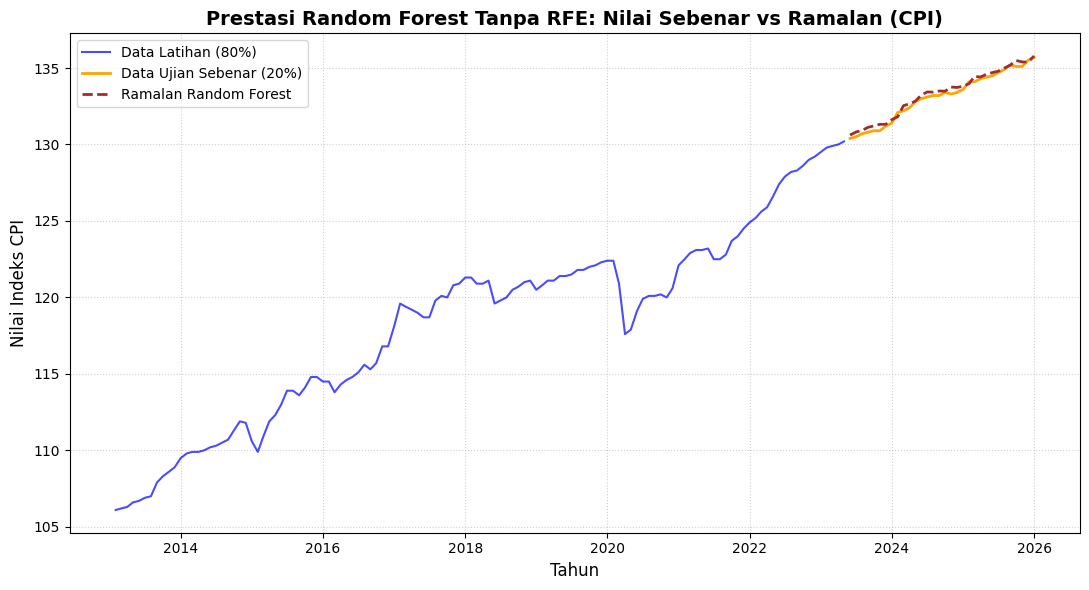

In [167]:
# 6. Plot graf perbandingan
plt.figure(figsize=(11, 6))

plt.plot(y_latih_asal, label='Data Latihan (80%)', color='blue', alpha=0.7)
plt.plot(y_uji_asal, label='Data Ujian Sebenar (20%)', color='orange', linewidth=2)
plt.plot(ramalan_rf_index1, label='Ramalan Random Forest', color='brown', linestyle='--', linewidth=2)

plt.title('Prestasi Random Forest Tanpa RFE: Nilai Sebenar vs Ramalan (CPI)', fontsize=14, fontweight='bold')
plt.xlabel('Tahun', fontsize=12)
plt.ylabel('Nilai Indeks CPI', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

###**XGBOOST**

In [130]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFECV
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [131]:
# 1. Piawaikan data
scaler_xgb = StandardScaler()
X_latih_skala_xgb = scaler_xgb.fit_transform(X_latih)
X_uji_skala_xgb = scaler_xgb.transform(X_uji)

In [132]:
# 2. Menapis data menggunakan recursive elimination (RFE)
xgb_rfe = XGBRegressor(random_state=42, objective='reg:squarederror')
penapis_rfe_xgb = RFECV(estimator=xgb_rfe, step=1, cv=5, scoring='neg_mean_absolute_error')
penapis_rfe_xgb.fit(X_latih_skala_xgb, y_latih_diff)

X_latih_rfe_xgb = penapis_rfe_xgb.transform(X_latih_skala_xgb)
X_uji_rfe_xgb = penapis_rfe_xgb.transform(X_uji_skala_xgb)

In [133]:
# 3. Memperkemas model melalui gridsearchcv
xgb_asas = XGBRegressor(random_state=42, objective='reg:squarederror')
parameter_grid_xgb = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7]}

grid_search_xgb = GridSearchCV(xgb_asas, parameter_grid_xgb, cv=5, scoring='neg_mean_absolute_error')
grid_search_xgb.fit(X_latih_rfe_xgb, y_latih_diff)
model_xgb_terbaik = grid_search_xgb.best_estimator_
print(f"Kombinasi Parameter Pemenang: {grid_search_xgb.best_params_}")

Kombinasi Parameter Pemenang: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 50}


###**RAMALAN & UJIAN DATA XGBOOST**

In [134]:
# 1. Buat ramalan dan transformasi songsang
ramalan_xgb_diff = model_xgb_terbaik.predict(X_uji_rfe_xgb)
ramalan_xgb_index = cpi_semalam + ramalan_xgb_diff
ramalan_xgb_index = pd.Series(ramalan_xgb_index, index=y_uji_asal.index)

In [135]:
# 2. Penilaian prestasi
r2_xgb = r2_score(y_uji_asal, ramalan_xgb_index)
mae_xgb = mean_absolute_error(y_uji_asal, ramalan_xgb_index)
rmse_xgb = np.sqrt(mean_squared_error(y_uji_asal, ramalan_xgb_index))

In [136]:
# 3. Papar keputusan akhir
print("\n" + "="*45)
print(" PRESTASI RAMALAN XGBOOST ".center(45))
print("="*45)
print(f" Nilai R-Squared (R2) : {r2_xgb:.4f}")
print(f" Nilai MAE  : {mae_xgb:.4f}")
print(f" Nilai RMSE : {rmse_xgb:.4f}")
print("="*45 + "\n")


           PRESTASI RAMALAN XGBOOST          
 Nilai R-Squared (R2) : 0.9892
 Nilai MAE  : 0.1193
 Nilai RMSE : 0.1663



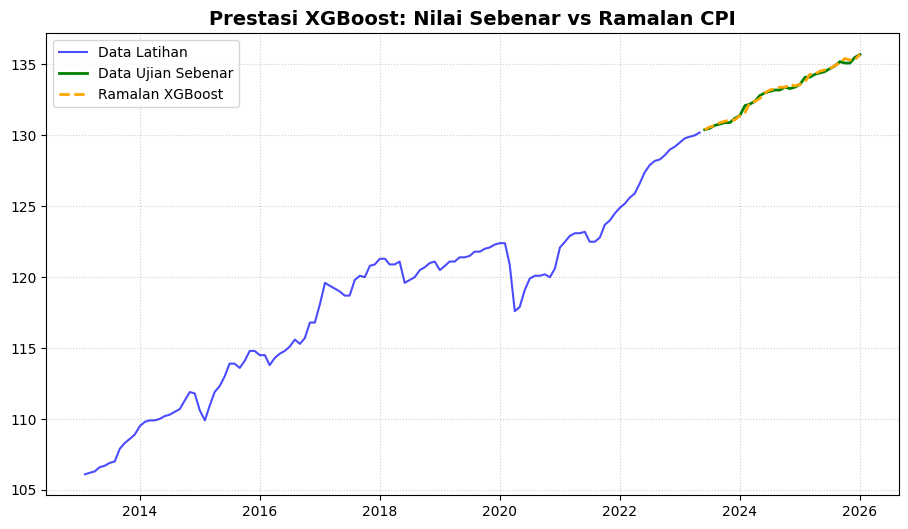

In [137]:
# 4. Plot graf perbandingan
plt.figure(figsize=(11, 6))

plt.plot(y_latih_asal, label='Data Latihan', color='blue', alpha=0.7)
plt.plot(y_uji_asal, label='Data Ujian Sebenar', color='green', linewidth=2)
plt.plot(ramalan_xgb_index, label='Ramalan XGBoost', color='orange', linestyle='--', linewidth=2)

plt.title('Prestasi XGBoost: Nilai Sebenar vs Ramalan CPI', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

###**XGBOOST TANPA RFE**

In [168]:
# 1. Piawaikan data
scaler_xgb1 = StandardScaler()
X_latih_skala_xgb1 = scaler_xgb1.fit_transform(X_latih)
X_uji_skala_xgb1 = scaler_xgb1.transform(X_uji)

In [169]:
# 2. Memperkemaskan model melalui gridsearchcv
xgb_asas1 = XGBRegressor(random_state=42, objective='reg:squarederror')
parameter_grid_xgb1 = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7]}

grid_search_xgb1 = GridSearchCV(xgb_asas1, parameter_grid_xgb1, cv=5, scoring='neg_mean_absolute_error')

In [172]:
# 3. Latih menggunakan data yang telah dipiawaikan (Tanpa RFE)
grid_search_xgb1.fit(X_latih_skala_xgb1, y_latih_diff)
model_xgb_terbaik1 = grid_search_xgb1.best_estimator_

###**RAMALAN & UJIAN DATA XGBOOST TANPA RFE**

In [173]:
# 1. Buat ramalan dan transformasi songsang
ramalan_xgb_diff1 = model_xgb_terbaik1.predict(X_uji_skala_xgb1)
ramalan_xgb_index1 = cpi_semalam + ramalan_xgb_diff1
ramalan_xgb_index1 = pd.Series(ramalan_xgb_index1, index=y_uji_asal.index)

In [174]:
# 1. Penilaian prestasi
r2_xgb1 = r2_score(y_uji_asal, ramalan_xgb_index1)
mae_xgb1 = mean_absolute_error(y_uji_asal, ramalan_xgb_index1)
rmse_xgb1 = np.sqrt(mean_squared_error(y_uji_asal, ramalan_xgb_index1))

In [175]:
# 3. Papar keputusan akhir
print("\n" + "="*45)
print(" PRESTASI RAMALAN XGBOOST TANPA RFE".center(45))
print("="*45)
print(f" Nilai R-Squared (R2) : {r2_xgb1:.4f}")
print(f" Nilai MAE  : {mae_xgb1:.4f}")
print(f" Nilai RMSE : {rmse_xgb1:.4f}")
print("="*45 + "\n")


      PRESTASI RAMALAN XGBOOST TANPA RFE     
 Nilai R-Squared (R2) : 0.9876
 Nilai MAE  : 0.1442
 Nilai RMSE : 0.1784



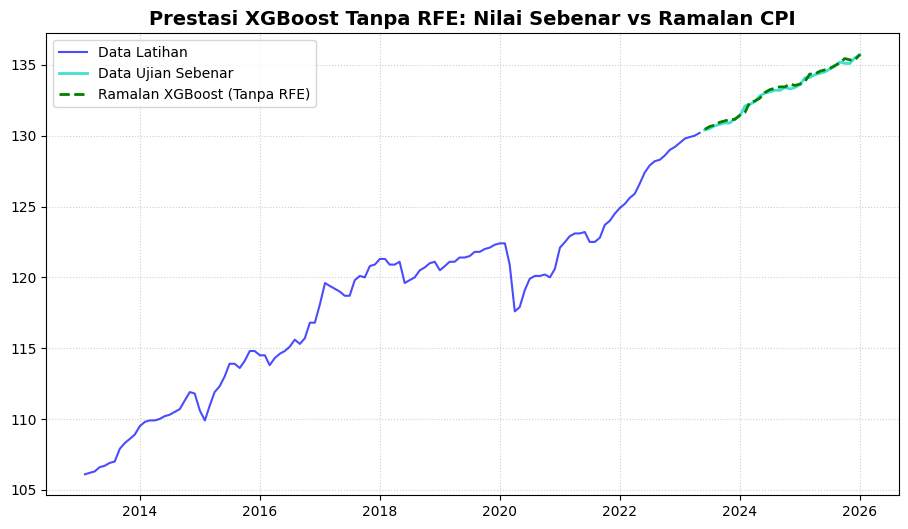

In [176]:
# 4. Plot graf perbandingan
plt.figure(figsize=(11, 6))
plt.plot(y_latih_asal, label='Data Latihan', color='blue', alpha=0.7)
plt.plot(y_uji_asal, label='Data Ujian Sebenar', color='turquoise', linewidth=2)
plt.plot(ramalan_xgb_index1, label='Ramalan XGBoost (Tanpa RFE)', color='green', linestyle='--', linewidth=2)
plt.title('Prestasi XGBoost Tanpa RFE: Nilai Sebenar vs Ramalan CPI', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

###**SHAP ANALYSIS**

--- MENJANA ANALISIS SHAP GABUNGAN (ALL-IN-ONE) ---
Melatih semula model menggunakan 5 pembolehubah untuk perbandingan adil...


Mengira impak SHAP...

Jadual Purata Impak SHAP (|SHAP Value|):
                      Lasso  Random Forest   XGBoost
Pembolehubah                                        
OPR_Rate           0.081014       0.003872  0.018361
PPI_Index          0.067745       0.057158  0.081128
Unemployment_Rate  0.133784       0.052692  0.090499
M3_Total           0.235075       0.020757  0.045334
USD_Avg            0.073596       0.044707  0.066715


<Figure size 1200x700 with 0 Axes>

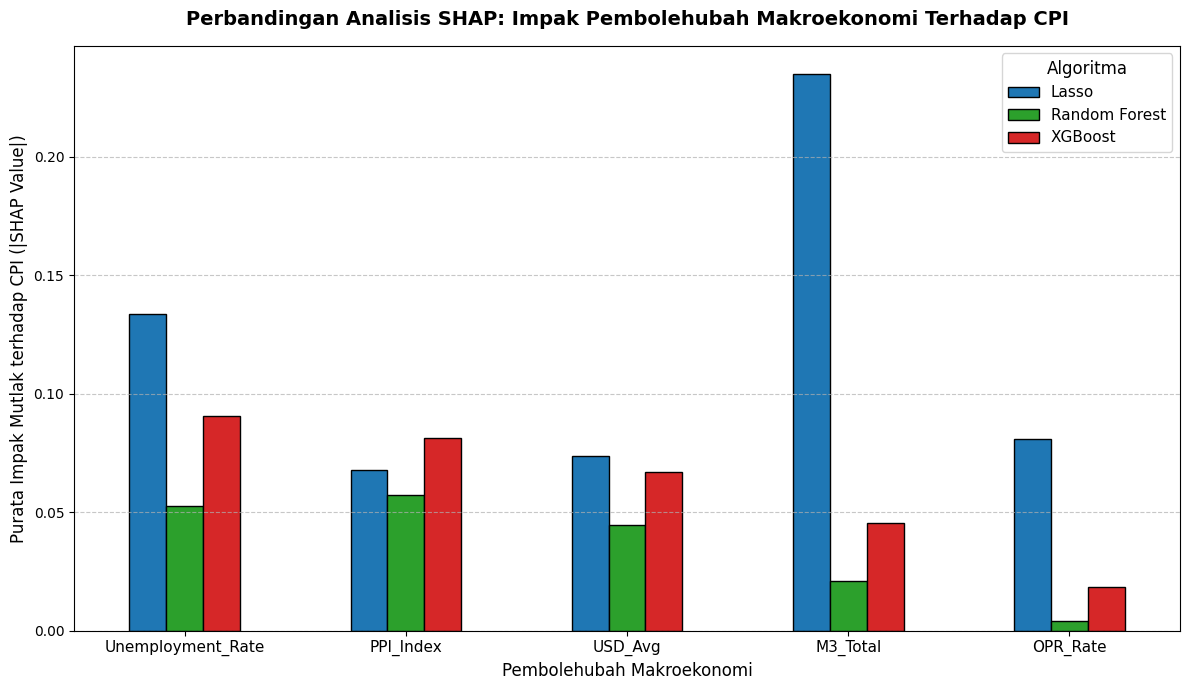

In [179]:
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

print("--- MENJANA ANALISIS SHAP GABUNGAN (ALL-IN-ONE) ---")

# =======================================================
# 1. MELATIH SEMULA MODEL (TANPA RFE) UNTUK KESERAGAMAN MEMORI
# =======================================================
print("Melatih semula model menggunakan 5 pembolehubah untuk perbandingan adil...")
# A. Lasso
model_lasso_shap = Lasso(alpha=0.01, random_state=42)
model_lasso_shap.fit(X_latih_skala_xgb, y_latih_diff)

# B. Random Forest
model_rf_shap = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf_shap.fit(X_latih_skala_xgb, y_latih_diff)

# C. XGBoost
model_xgb_shap = XGBRegressor(n_estimators=100, random_state=42, objective='reg:squarederror')
model_xgb_shap.fit(X_latih_skala_xgb, y_latih_diff)

# =======================================================
# 2. PENGKIRAAN SHAP UNTUK SETIAP MODEL
# =======================================================
print("Mengira impak SHAP...")
# A. Model Lasso (Guna LinearExplainer)
explainer_lasso = shap.LinearExplainer(model_lasso_shap, X_latih_skala_xgb)
nilai_shap_lasso = explainer_lasso.shap_values(X_uji_skala_xgb)

# B. Model Random Forest (Guna TreeExplainer)
explainer_rf = shap.TreeExplainer(model_rf_shap)
nilai_shap_rf = explainer_rf.shap_values(X_uji_skala_xgb)

# C. Model XGBoost (Guna TreeExplainer)
explainer_xgb = shap.TreeExplainer(model_xgb_shap)
nilai_shap_xgb = explainer_xgb.shap_values(X_uji_skala_xgb)

# =======================================================
# 3. MENGIRA PURATA IMPAK MUTLAK (Mean Absolute SHAP)
# =======================================================
purata_shap_lasso = np.abs(nilai_shap_lasso).mean(axis=0)
purata_shap_rf = np.abs(nilai_shap_rf).mean(axis=0)
purata_shap_xgb = np.abs(nilai_shap_xgb).mean(axis=0)

# =======================================================
# 4. MEMBINA JADUAL GABUNGAN (DATAFRAME)
# =======================================================
df_shap_gabungan = pd.DataFrame({
    'Pembolehubah': pembolehubah_x,
    'Lasso': purata_shap_lasso,
    'Random Forest': purata_shap_rf,
    'XGBoost': purata_shap_xgb
})

# Menjadikan nama pembolehubah sebagai indeks untuk plot graf
df_shap_gabungan.set_index('Pembolehubah', inplace=True)

# Memaparkan jadual teks
print("\nJadual Purata Impak SHAP (|SHAP Value|):")
print(df_shap_gabungan)

# =======================================================
# 5. VISUALISASI: CARTA PALANG BERKELOMPOK
# =======================================================
# Menyusun jadual mengikut kekuatan XGBoost
df_shap_gabungan_disusun = df_shap_gabungan.sort_values(by='XGBoost', ascending=False)

plt.figure(figsize=(12, 7))
df_shap_gabungan_disusun.plot(kind='bar', figsize=(12, 7), color=['#1f77b4', '#2ca02c', '#d62728'], edgecolor='black')

plt.title('Perbandingan Analisis SHAP: Impak Pembolehubah Makroekonomi Terhadap CPI', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Pembolehubah Makroekonomi', fontsize=12)
plt.ylabel('Purata Impak Mutlak terhadap CPI (|SHAP Value|)', fontsize=12)
plt.xticks(rotation=0, fontsize=11)
plt.legend(title='Algoritma', fontsize=11, title_fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()